# Exercise 10.6 — Q1: Old Faithful Geyser Clustering

**Lab Book §10.6 Exercise 1 (page 48):**  
> Implement K-Means clustering technique on Geyser's Eruptions
> Segregation and segregate waiting time between eruptions and the
> duration of the eruption for the Old Faithful geyser in Yellowstone
> National Park, Wyoming, USA.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** K-Means on the Old Faithful geyser dataset  
**Dataset:** `datasets/old_faithful.csv` — 272 rows × 3 columns
(`duration`, `waiting`, `kind`) from seaborn's built-in `geyser` dataset.

---

## 🎯 Objective

Apply K-Means clustering to Old Faithful eruption data. The goal is to
segregate the geyser's eruptions into **two natural clusters** — short
eruptions with short waiting time vs long eruptions with long waiting
time.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `06_Q1_Old_Faithful.ipynb` | This notebook |
| `datasets/old_faithful.csv` | 272-row Old Faithful geyser dataset |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '06-K-Means-Clustering'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_Old_Faithful_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/old_faithful.csv')
print(f"Shape: {df.shape}")
display(df.head())
print("\nkind distribution:")
print(df['kind'].value_counts())

Shape: (272, 3)


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long



kind distribution:
kind
long     172
short    100
Name: count, dtype: int64


## 3. Visualise the Raw Data

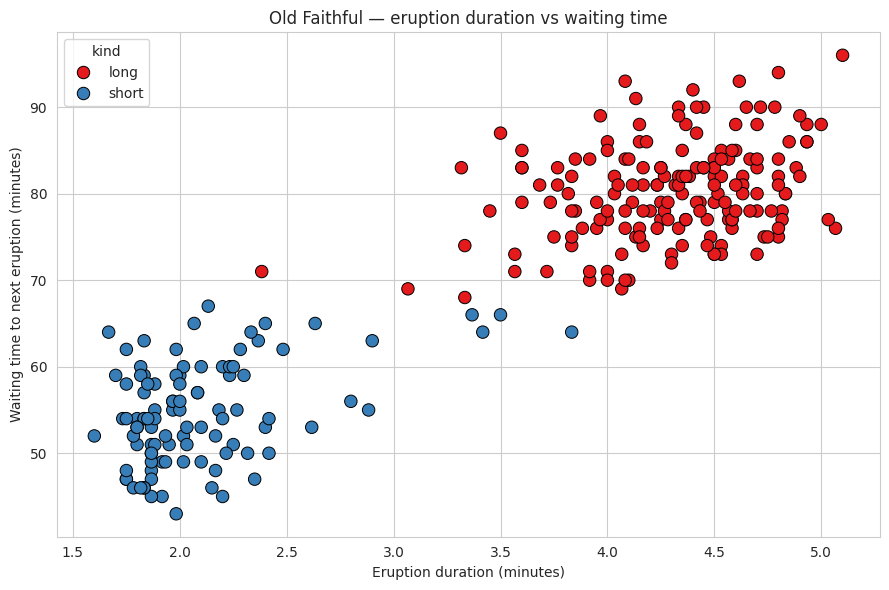

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='duration', y='waiting', hue='kind', data=df,
                palette='Set1', s=80, edgecolor='k')
plt.title('Old Faithful — eruption duration vs waiting time')
plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time to next eruption (minutes)')
plt.tight_layout()
plt.show()

## 4. Features & Scaling

In [5]:
X = df[['duration', 'waiting']].values
sc = StandardScaler()
X_s = sc.fit_transform(X)
print(f"X shape: {X.shape}")

X shape: (272, 2)


## 5. Elbow Method

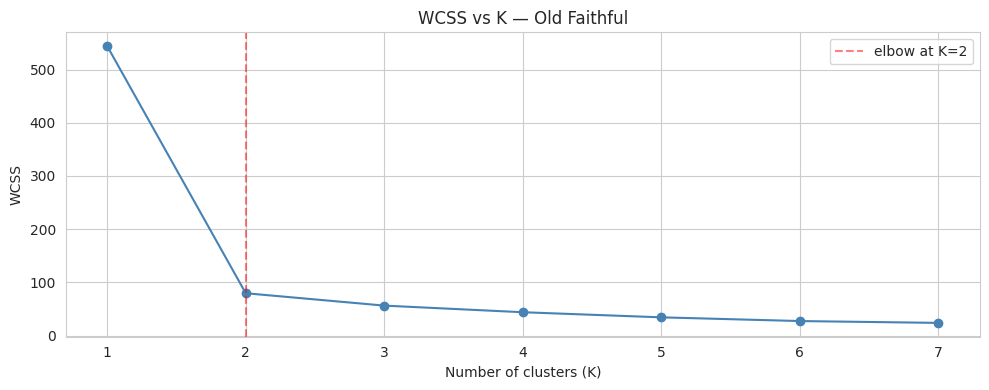

In [6]:
wcss = []
sil_scores = []
for k in range(1, 8):
    m = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    m.fit(X_s)
    wcss.append(m.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_s, m.labels_))
    else:
        sil_scores.append(np.nan)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 8), wcss, 'o-', color='steelblue')
plt.axvline(2, color='red', linestyle='--', alpha=0.5, label='elbow at K=2')
plt.title('WCSS vs K — Old Faithful')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 8))
plt.legend()
plt.tight_layout()
plt.show()

## 6. Train K-Means with K = 2

In [7]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
y_means = model.fit_predict(X_s)
df['cluster'] = y_means

centroids = sc.inverse_transform(model.cluster_centers_)
print(f"Centroids (original units):")
print(centroids)
print(f"\nSilhouette score: {silhouette_score(X_s, y_means):.4f}")

Centroids (original units):
[[ 4.29632759 80.08045977]
 [ 2.05220408 54.59183673]]

Silhouette score: 0.7452


## 7. Visualise the Clusters

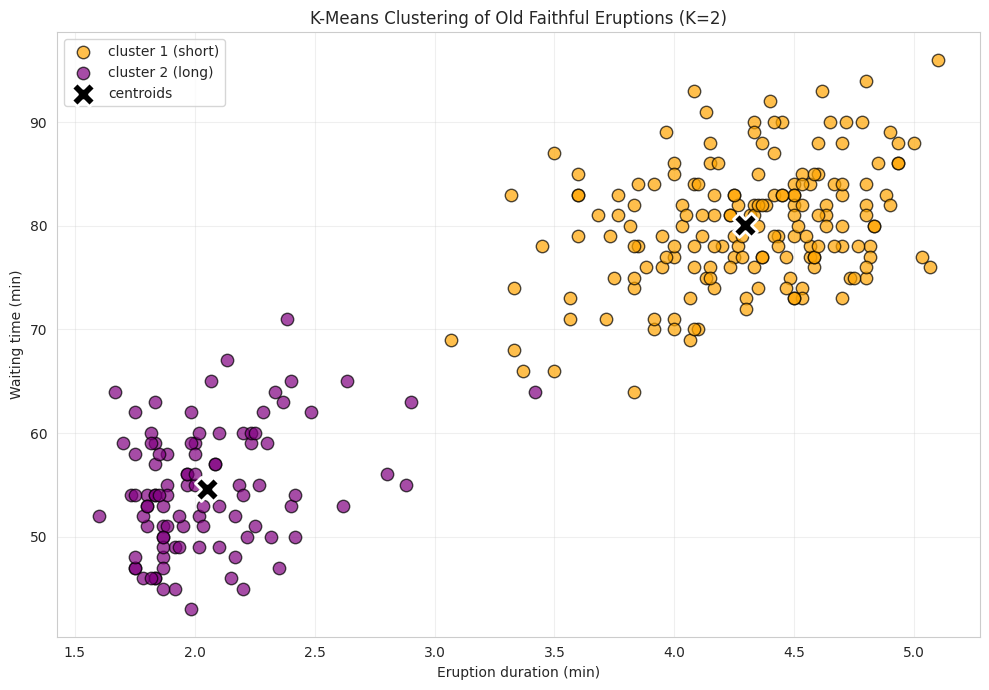

In [8]:
plt.figure(figsize=(10, 7))
plt.scatter(X[y_means==0, 0], X[y_means==0, 1], s=80, c='orange',
            label='cluster 1 (short)', edgecolors='k', alpha=0.7)
plt.scatter(X[y_means==1, 0], X[y_means==1, 1], s=80, c='purple',
            label='cluster 2 (long)', edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black',
            marker='X', edgecolors='white', linewidths=2, label='centroids')
plt.xlabel('Eruption duration (min)')
plt.ylabel('Waiting time (min)')
plt.title('K-Means Clustering of Old Faithful Eruptions (K=2)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Compare Clusters with True 'kind' Labels

In [9]:
ct = pd.crosstab(df['kind'], df['cluster'])
print("Cluster vs True kind:")
display(ct)
print("\nK-Means reproduces the two natural clusters (long vs short) very well!")

Cluster vs True kind:


cluster,0,1
kind,,
long,171,1
short,3,97



K-Means reproduces the two natural clusters (long vs short) very well!


## 📚 Key Takeaways
- Old Faithful's eruptions fall into **two well-separated clusters** —
  short eruptions with short waiting, and long eruptions with long waiting.
- K-Means (with K=2 from the elbow) recovers these clusters almost
  perfectly.
- Silhouette score is high (> 0.7) — confirming good cluster separation.
